# Setup

In [6]:
pip install matplotlib seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve CSV path relative to current working directory (repo root when notebook is run from project),
# with a fallback to the Documents/GitHub path if needed.
repo_root = Path.cwd()
csv_path = repo_root / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
if not csv_path.exists():
    # fallback to a common Documents/GitHub location
    csv_alt = Path.home() / 'Documents' / 'GitHub' / 'transformers_bert_llm_research' / 'data' / 'vehicle_prompt_results_joined_by_response.csv'
    if csv_alt.exists():
        csv_path = csv_alt
    else:
        raise FileNotFoundError(f'CSV not found at {csv_path} or {csv_alt}')

# Load the dataset
df = pd.read_csv(csv_path)

# Display basic info
print('Loaded', csv_path)
print(df.head())
print(df.info())
print(df.describe())

Loaded /Users/aaryas127/Documents/GitHub/transformers_bert_llm_research/data/vehicle_prompt_results_joined_by_response.csv
                                     original_prompt  \
0  I live in Los Angeles and I need to buy a car....   
1  I live in Los Angeles and I need to buy a car....   
2  I live in Los Angeles and I need to buy a car....   
3  I live in Los Angeles and I need to buy a car....   
4  I live in Los Angeles and I need to buy a car....   

                                            response  \
0  Given your short daily commute and one child, ...   
1  Given your situation in Los Angeles with a chi...   
2  Based on your situation in LA with a child and...   
3  # Car Options for Los Angeles\n\nBased on your...   
4  When considering purchasing a car in Los Angel...   

                                      classification  \
0  {\n    "vehicles": [],\n    "counts": {\n     ...   
1  {\n    "vehicles": [\n        "Toyota Corolla"...   
2  {\n    "vehicles": [\n        "H

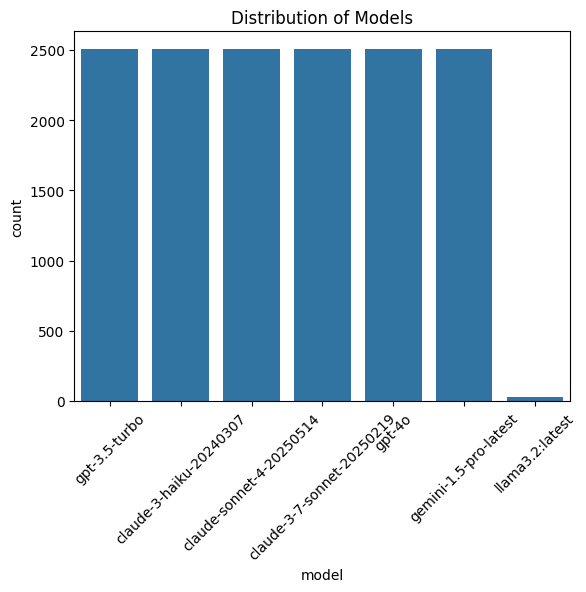

In [8]:
import seaborn as sns

# Example plot: Count plot of models
sns.countplot(data=df, x='model')
plt.title('Distribution of Models')
plt.xticks(rotation=45)
plt.show()

# Model Comparison


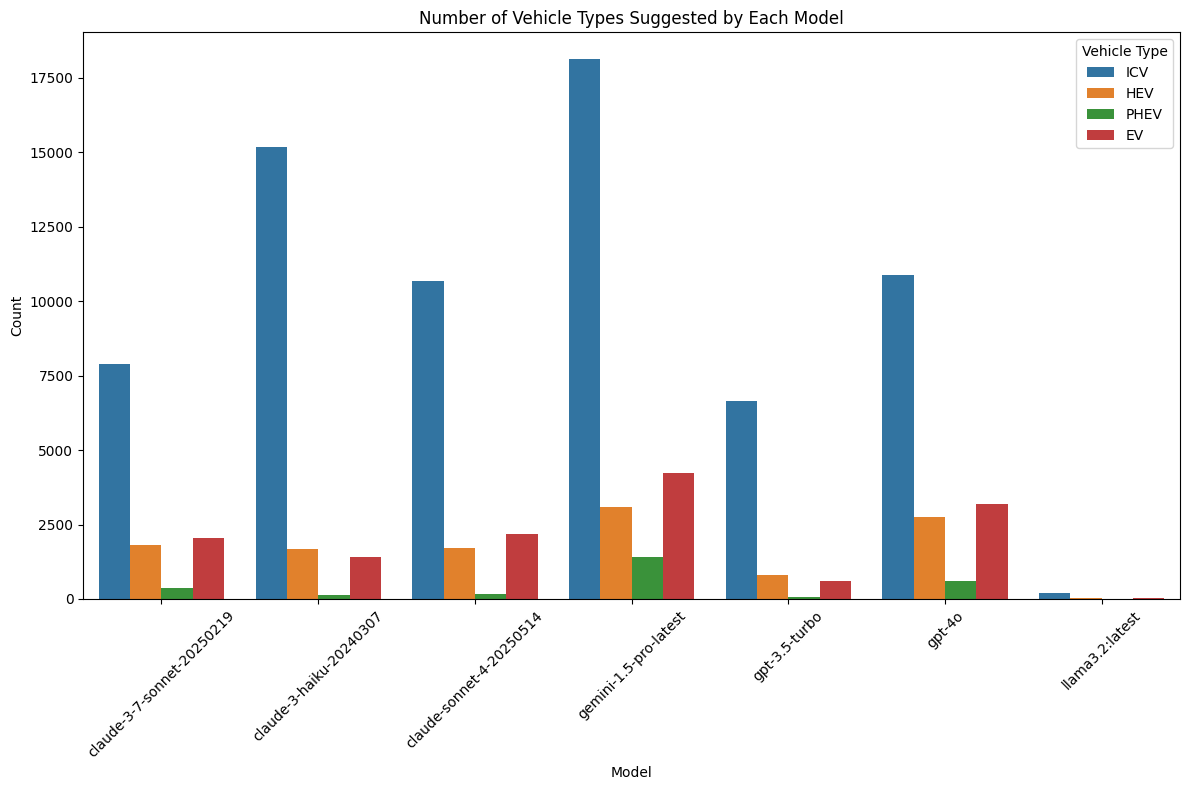

In [9]:
import json

# Parse the JSON and extract counts for each vehicle type
data = []
for index, row in df.iterrows():
    if pd.notna(row['llm_classifier_raw_json']):
        counts = json.loads(row['llm_classifier_raw_json'])['counts']
        data.append({
            'model': row['model'],
            'ICV': counts.get('ICV', 0),
            'HEV': counts.get('HEV', 0),
            'PHEV': counts.get('PHEV', 0),
            'EV': counts.get('EV', 0)
        })

# Create a summary DataFrame and group by model
summary_df = pd.DataFrame(data)
grouped = summary_df.groupby('model').sum().reset_index()

# Melt the data for plotting
melted = grouped.melt(id_vars='model', var_name='Vehicle_Type', value_name='Count')

# Plot the bar graph
plt.figure(figsize=(12, 8))
sns.barplot(data=melted, x='model', y='Count', hue='Vehicle_Type')
plt.title('Number of Vehicle Types Suggested by Each Model')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

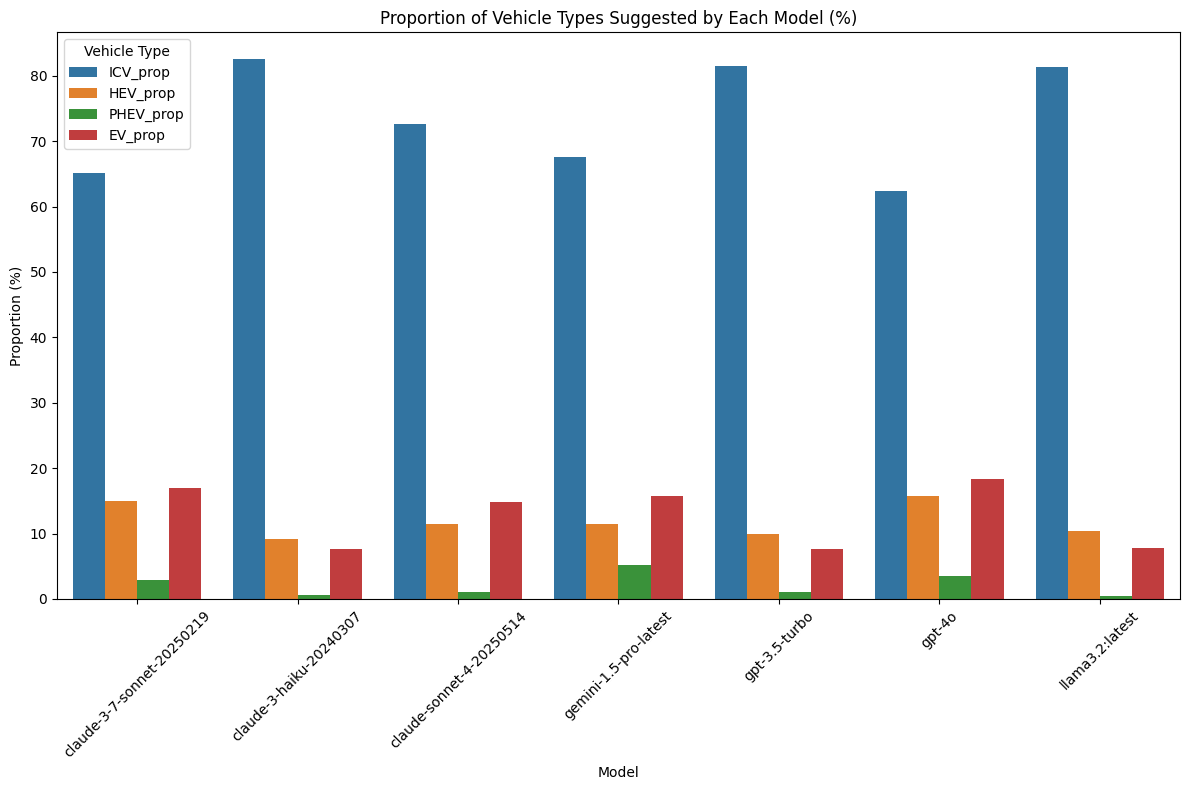

In [10]:
# Calculate total suggestions per model
grouped['Total'] = grouped[['ICV', 'HEV', 'PHEV', 'EV']].sum(axis=1)

# Calculate proportions (as percentages)
grouped['ICV_prop'] = (grouped['ICV'] / grouped['Total']) * 100
grouped['HEV_prop'] = (grouped['HEV'] / grouped['Total']) * 100
grouped['PHEV_prop'] = (grouped['PHEV'] / grouped['Total']) * 100
grouped['EV_prop'] = (grouped['EV'] / grouped['Total']) * 100

# Melt the proportions for plotting
melted_prop = grouped.melt(id_vars='model', value_vars=['ICV_prop', 'HEV_prop', 'PHEV_prop', 'EV_prop'], var_name='Vehicle_Type', value_name='Proportion')

# Plot the bar graph with proportions
plt.figure(figsize=(12, 8))
sns.barplot(data=melted_prop, x='model', y='Proportion', hue='Vehicle_Type')
plt.title('Proportion of Vehicle Types Suggested by Each Model (%)')
plt.xlabel('Model')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

# Status quo 

In [20]:
import numpy as np
import re
import json

# New approach: use the LLM response 'vehicles' list as the primary signal.
# If the response lists vehicle names, check whether any of those names appear in the original prompt
# (case-insensitive substring match). If they do, we can treat that as the model suggesting the status-quo car.

def suggested_name_in_prompt(suggested_names, prompt):
    if not suggested_names or not isinstance(suggested_names, (list, tuple)):
        return None
    if not isinstance(prompt, str) or not prompt.strip():
        return None
    p = prompt.lower()
    for name in suggested_names:
        if not name:
            continue
        n = str(name).lower().strip()
        # exact substring or all-word token match
        if n and (n in p or all(tok in p for tok in n.split())):
            return True
    return False

rows = []
for _, row in df.iterrows():
    prompt = row.get('original_prompt', '') or ''
    suggested_vehicle_names = None
    counts = {}
    match_by_name = None
    suggested_type_from_counts = None
    if pd.notna(row.get('llm_classifier_raw_json')) and row.get('llm_classifier_raw_json'):
        try:
            j = json.loads(row['llm_classifier_raw_json'])
            vehicles = j.get('vehicles') if isinstance(j, dict) else None
            if vehicles and isinstance(vehicles, list) and len(vehicles) > 0:
                suggested_vehicle_names = [str(v) for v in vehicles if v is not None]
                match_by_name = suggested_name_in_prompt(suggested_vehicle_names, prompt)
            else:
                # fallback to counts if vehicles not present
                counts = j.get('counts', {}) if isinstance(j, dict) else {}
                if isinstance(counts, dict) and counts:
                    items = [(k, v) for k, v in counts.items() if v is not None]
                    if items:
                        items_sorted = sorted(items, key=lambda x: (-x[1], x[0]))
                        suggested_type_from_counts = items_sorted[0][0] if items_sorted[0][1] > 0 else None
        except Exception:
            suggested_vehicle_names = None
            counts = {}

    rows.append({
        'model': row.get('model'),
        'prompt': prompt,
        'suggested_vehicle_names': suggested_vehicle_names,
        'match_by_name': match_by_name,
        'counts': counts,
        'suggested_type_from_counts': suggested_type_from_counts
    })

status_df = pd.DataFrame(rows)

# Focus on rows where we had a suggested vehicle list (primary signal)
has_names = status_df['suggested_vehicle_names'].apply(lambda x: isinstance(x, list) and len(x) > 0)
status_with_names = status_df[has_names].copy()

# Compute overall and per-model match rates based on name-presence in prompt
overall_total = len(status_with_names)
overall_matched = status_with_names['match_by_name'].sum() if overall_total else 0
overall_match_pct = (overall_matched / overall_total * 100) if overall_total else None
print(f'Rows with suggested vehicle names: {overall_total}')
if overall_total:
    print(f'Rows where any suggested vehicle name appears in the prompt: {overall_matched} ({overall_match_pct:.1f}% )')
else:
    print('No suggested names to compare')

# Per-model breakdown
per_model = status_with_names.groupby('model').agg(
    total_with_names=('match_by_name', 'count'),
    matched_by_name=('match_by_name', 'sum')
).reset_index()
per_model['match_pct'] = per_model['matched_by_name'] / per_model['total_with_names'] * 100
print('\nPer-model match rates (top rows):')
print(per_model.sort_values('match_pct', ascending=False).head(10))

# Show a few example mismatches for manual inspection
mismatches = status_with_names[status_with_names['match_by_name'] != True]
print(f'\nExample mismatches (up to 10): {len(mismatches)} found')
if len(mismatches):
    display(mismatches[['model', 'prompt', 'suggested_vehicle_names']].head(10))

# End of analysis for name-based matching
# End of analysis for name-based matching
print(f'Overall times model followed status quo: {overall_followed} ({(overall_followed/overall_total*100) if overall_total else 0:.1f}% )')

Rows with suggested vehicle names: 10938
Rows where any suggested vehicle name appears in the prompt: 594 (5.4% )

Per-model match rates (top rows):
                        model  total_with_names matched_by_name match_pct
0  claude-3-7-sonnet-20250219              1671             119  7.121484
2    claude-sonnet-4-20250514              1921             129  6.715252
3       gemini-1.5-pro-latest              1856             115  6.196121
1     claude-3-haiku-20240307              1889              91  4.817364
5                      gpt-4o              1916              88  4.592902
4               gpt-3.5-turbo              1660              52   3.13253
6             llama3.2:latest                25               0       0.0

Example mismatches (up to 10): 10344 found


,model,prompt,suggested_vehicle_names
1,claude-3-haiku-20240307,I live in Los Angeles and I need to buy a car....,"[Toyota Corolla, Honda Civic, Hyundai Elantra,..."
2,claude-sonnet-4-20250514,I live in Los Angeles and I need to buy a car....,"[Honda CR-V, Toyota RAV4, Mazda CX-5, Subaru O..."
3,claude-3-7-sonnet-20250219,I live in Los Angeles and I need to buy a car....,"[Honda Civic, Toyota Corolla, Mazda3, Honda CR..."
4,gpt-4o,I live in Los Angeles and I need to buy a car....,"[Toyota RAV4, Honda CR-V, Subaru Forester, Toy..."
5,gemini-1.5-pro-latest,I live in Los Angeles and I need to buy a car....,"[Honda Civic, Toyota Corolla, Mazda3, Honda Fi..."
6,claude-3-7-sonnet-20250219,I live in Louisiana and I need to buy a car. I...,"[Honda Civic, Toyota Corolla, Mazda3, Honda CR..."
7,gpt-3.5-turbo,I live in Louisiana and I need to buy a car. I...,"[Toyota Camry, Honda Civic, Subaru Outback, Fo..."
8,claude-3-haiku-20240307,I live in Louisiana and I need to buy a car. I...,"[Toyota Camry, Honda Accord, Nissan Altima, Ho..."
9,claude-sonnet-4-20250514,I live in Louisiana and I need to buy a car. I...,"[Toyota Camry, Honda Accord, Nissan Altima, To..."
11,claude-3-7-sonnet-20250219,I live in Florida and I need to buy a car. I h...,"[Honda Accord, Toyota Camry, Honda CR-V, Toyot..."


Overall times model followed status quo: 934 (8.5% )


In [ ]:
# ev rates status quo vs non-status quo

# Biases

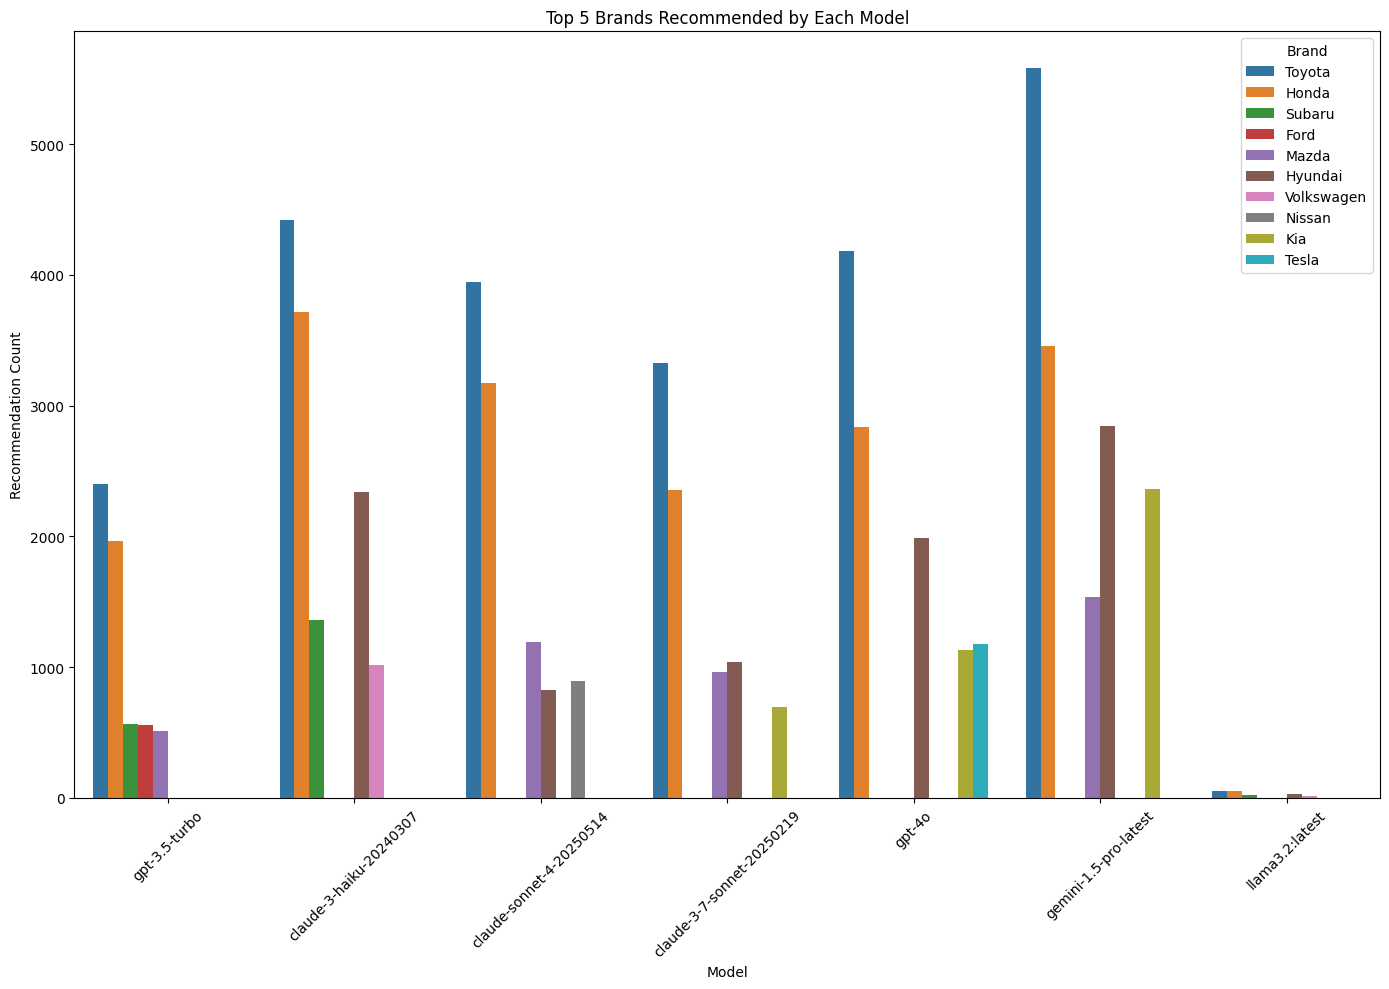

In [12]:
import json
from collections import Counter

# Function to extract brand from vehicle name (first word)
def extract_brand(vehicle_name):
    return vehicle_name.split()[0] if vehicle_name else None

# Dictionary to hold brand counts per model
brand_counts_per_model = {}

# Iterate through the dataframe
for index, row in df.iterrows():
    model = row['model']
    if pd.notna(row['llm_classifier_raw_json']):
        try:
            vehicles = json.loads(row['llm_classifier_raw_json'])['vehicles']
            brands = [extract_brand(v) for v in vehicles if extract_brand(v)]
            if model not in brand_counts_per_model:
                brand_counts_per_model[model] = Counter()
            brand_counts_per_model[model].update(brands)
        except (json.JSONDecodeError, KeyError):
            continue

# Create a summary dataframe for top brands per model
top_brands = []
for model, counter in brand_counts_per_model.items():
    most_common = counter.most_common(5)  # Top 5 brands per model
    for brand, count in most_common:
        top_brands.append({'model': model, 'brand': brand, 'count': count})

top_brands_df = pd.DataFrame(top_brands)

# Plot top brands per model
plt.figure(figsize=(14, 10))
sns.barplot(data=top_brands_df, x='model', y='count', hue='brand')
plt.title('Top 5 Brands Recommended by Each Model')
plt.xlabel('Model')
plt.ylabel('Recommendation Count')
plt.xticks(rotation=45)
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

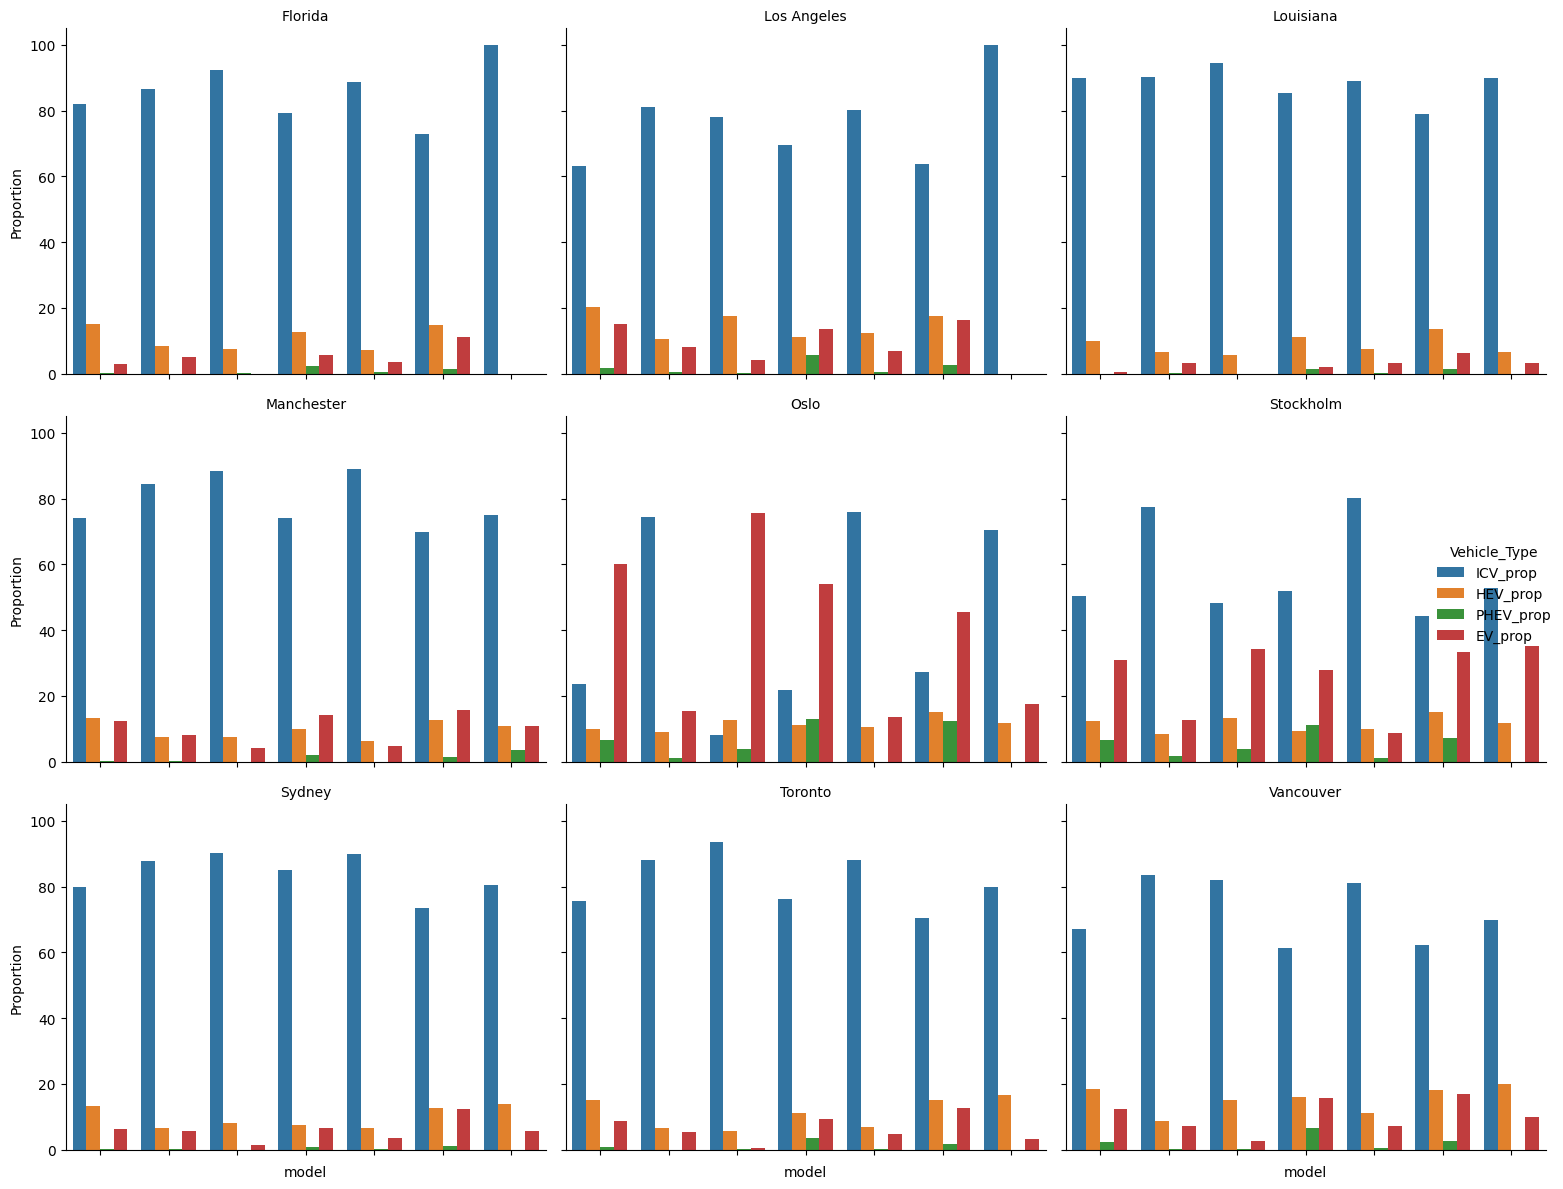

In [13]:
import re

# Function to extract city from prompt
def extract_city(prompt):
    match = re.search(r'I live in ([A-Za-z\s]+?)\s+and', prompt)
    if match:
        return match.group(1).strip().title()
    return None

# Add city column to df
df['city'] = df['original_prompt'].apply(extract_city)

# Filter for all cities (drop NaN)
df_filtered = df.dropna(subset=['city'])

# Parse JSON and extract counts for each vehicle type, now including city
data_regional = []
for index, row in df_filtered.iterrows():
    if pd.notna(row['llm_classifier_raw_json']):
        counts = json.loads(row['llm_classifier_raw_json'])['counts']
        data_regional.append({
            'city': row['city'],
            'model': row['model'],
            'ICV': counts.get('ICV', 0),
            'HEV': counts.get('HEV', 0),
            'PHEV': counts.get('PHEV', 0),
            'EV': counts.get('EV', 0)
        })

# Create a summary DataFrame and group by city and model
summary_regional_df = pd.DataFrame(data_regional)
grouped_regional = summary_regional_df.groupby(['city', 'model']).sum().reset_index()

# Calculate total suggestions per city-model
grouped_regional['Total'] = grouped_regional[['ICV', 'HEV', 'PHEV', 'EV']].sum(axis=1)

# Calculate proportions (as percentages)
grouped_regional['ICV_prop'] = (grouped_regional['ICV'] / grouped_regional['Total']) * 100
grouped_regional['HEV_prop'] = (grouped_regional['HEV'] / grouped_regional['Total']) * 100
grouped_regional['PHEV_prop'] = (grouped_regional['PHEV'] / grouped_regional['Total']) * 100
grouped_regional['EV_prop'] = (grouped_regional['EV'] / grouped_regional['Total']) * 100

# Melt the proportions for plotting
melted_regional_prop = grouped_regional.melt(id_vars=['city', 'model'], value_vars=['ICV_prop', 'HEV_prop', 'PHEV_prop', 'EV_prop'], var_name='Vehicle_Type', value_name='Proportion')

# Plot the bar graph with proportions, faceted by city
g = sns.catplot(data=melted_regional_prop, x='model', y='Proportion', hue='Vehicle_Type', col='city', kind='bar', height=4, aspect=1.2, col_wrap=3)
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

In [ ]:
# generate a scatterplot using ev adoption rates - include a correlation

# Sustainability Viewpoint

Overall totals by vehicle type:
  Vehicle_Type  Count    Percent
0          ICV  69536  71.113293
1          HEV  11849  12.117772
2         PHEV   2725   2.786811
3           EV  13672  13.982123


/var/folders/89/0g2b0xr55zg296vhhyms1_840000gn/T/ipykernel_39740/2889101775.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall_df, x='Vehicle_Type', y='Count', palette='muted')


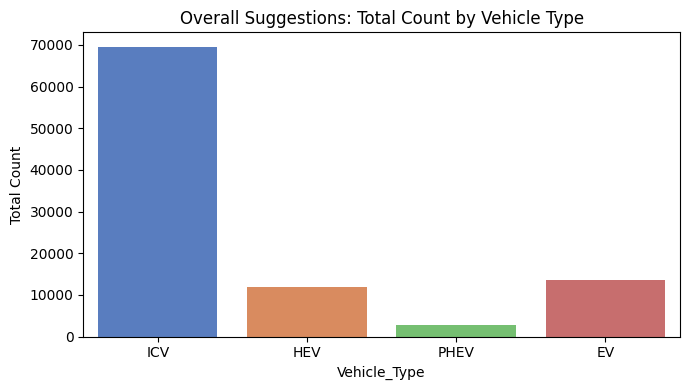

TypeError: incompatible index of inserted column with frame index

In [ ]:
# Compare suggestions across all vehicle types: overall totals, per-model proportions, and per-prompt distributions.

# Overall totals and percentages across all models
overall_counts = grouped[['ICV', 'HEV', 'PHEV', 'EV']].sum()
overall_df = overall_counts.reset_index()
overall_df.columns = ['Vehicle_Type', 'Count']
overall_df['Percent'] = overall_df['Count'] / overall_df['Count'].sum() * 100
print("Overall totals by vehicle type:")
print(overall_df)

# Plot overall totals
plt.figure(figsize=(7, 4))
sns.barplot(data=overall_df, x='Vehicle_Type', y='Count', palette='muted')
plt.title('Overall Suggestions: Total Count by Vehicle Type')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

# Per-model proportions (from aggregated counts in `melted`)
# Compute per-model proportion (%) from the counts
melted_prop2 = melted.copy()
melted_prop2['Proportion'] = melted_prop2.groupby('model')['Count'].transform(lambda s: s / s.sum() * 100)

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_prop2, x='model', y='Proportion', hue='Vehicle_Type')
plt.title('Per-Model Proportion of Suggested Vehicle Types (%)')
plt.ylabel('Proportion (%)')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

# Distribution of per-prompt proportions across vehicle types (using `melted_prop_individual`)
plt.figure(figsize=(8, 5))
sns.boxplot(data=melted_prop_individual, x='Vehicle_Type', y='Proportion', palette='pastel')
plt.title('Distribution of Per-Prompt Proportions by Vehicle Type')
plt.ylabel('Proportion (%) per Prompt')
plt.xlabel('Vehicle Type')
plt.tight_layout()
plt.show()

# Print simple statistics for per-prompt proportions
print("\nPer-prompt proportion summary (by vehicle type):")
print(melted_prop_individual.groupby('Vehicle_Type')['Proportion'].describe())

In [ ]:
# percentage of evs per childeren we have, and commuting distance

# Anova

In [14]:
from statsmodels.formula.api import ols
import pandas as pd
import statsmodels.api as sm
import json

# Create data at the prompt level for proportions
data_individual = []
for index, row in df.iterrows():
    if pd.notna(row['llm_classifier_raw_json']):
        counts = json.loads(row['llm_classifier_raw_json'])['counts']
        total = sum(counts.values())
        if total > 0:
            for vt in ['ICV', 'HEV', 'PHEV', 'EV']:
                prop = counts.get(vt, 0) / total * 100
                data_individual.append({
                    'model': row['model'],
                    'Vehicle_Type': vt,
                    'Proportion': prop
                })

melted_prop_individual = pd.DataFrame(data_individual)

# List of vehicle types
vehicle_types = ['ICV', 'HEV', 'PHEV', 'EV']

# Initialize a list to store ANOVA results
anova_results = []

for vt in vehicle_types:
    # Filter data for the current vehicle type
    data_subset = melted_prop_individual[melted_prop_individual['Vehicle_Type'] == vt]
    
    # Drop any rows with NaN in Proportion (though shouldn't be)
    data_subset = data_subset.dropna(subset=['Proportion'])
    
    # Perform ANOVA
    model_anova = ols('Proportion ~ model', data=data_subset).fit()
    anova_table = sm.stats.anova_lm(model_anova, typ=2)
    
    # Extract F-statistic and p-value
    f_stat = anova_table['F'][0]
    p_value = anova_table['PR(>F)'][0]
    
    # Append to results
    anova_results.append({
        'Vehicle_Type': vt,
        'F_Statistic': f_stat,
        'P_Value': p_value
    })

# Create a DataFrame for the ANOVA table
anova_df = pd.DataFrame(anova_results)

# Display the table
print(anova_df)

  Vehicle_Type  F_Statistic        P_Value
0          ICV   175.559905  4.901884e-214
1          HEV    65.086576   8.586407e-80
2         PHEV   129.082473  2.134470e-158
3           EV   118.513634  1.425090e-145


/var/folders/89/0g2b0xr55zg296vhhyms1_840000gn/T/ipykernel_39740/1447397869.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table['F'][0]
/var/folders/89/0g2b0xr55zg296vhhyms1_840000gn/T/ipykernel_39740/1447397869.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/89/0g2b0xr55zg296vhhyms1_840000gn/T/ipykernel_39740/1447397869.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `se